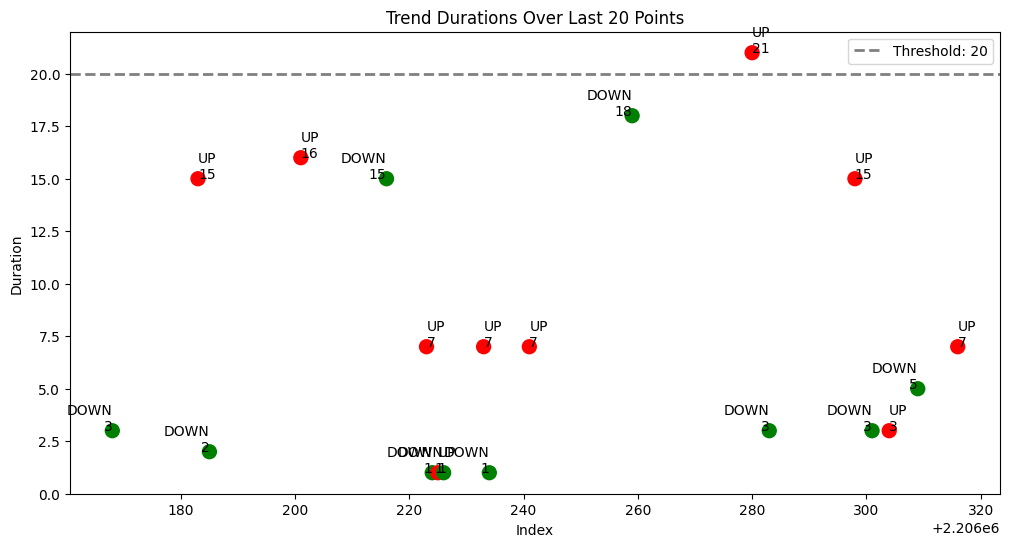

In [1]:
import feather
import pandas as pd
import talib
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
dataset_path = '/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-1m-futures.feather'
dataframe = feather.read_dataframe(dataset_path)

# Calculate Triple Exponential Moving Average (TEMA) on closing prices
tema_period = 50
dataframe['tema'] = talib.TEMA(dataframe['close'], timeperiod=tema_period)

# Establish the trend direction
conditions = [
    dataframe['tema'] > dataframe['tema'].shift(1),
    dataframe['tema'] < dataframe['tema'].shift(1)
]
choices = ['UP', 'DOWN']
dataframe['trend'] = np.select(conditions, choices, default='STABLE')

# Identify trend change points
dataframe['trend_change'] = dataframe['trend'] != dataframe['trend'].shift(1)
dataframe['trend_change_point'] = dataframe['trend_change'] & (dataframe['trend'] != 'STABLE')

# Create a separate DataFrame for change points to avoid SettingWithCopyWarning
change_points = dataframe[dataframe['trend_change_point']].copy()
change_points['duration'] = change_points.index.to_series().diff().fillna(0)

# Format data for plotting
change_points = change_points.round({'tema': 2, 'volume': 2})
if 'date' in change_points.columns:
    change_points['date'] = change_points['date'].dt.strftime('%Y-%m-%d %H:%M')

# Prepare for visualization
plot_data = change_points.copy()
plot_data['previous_trend'] = plot_data['trend'].shift(1)
plot_data.dropna(subset=['duration'], inplace=True)

# Define parameters for the plot
plot_window = 20
plot_data = plot_data.tail(plot_window)

# Create the scatter plot
plt.figure(figsize=(12, 6))
trend_colors = {'UP': 'green', 'DOWN': 'red', 'STABLE': 'blue'}
plt.scatter(plot_data.index, plot_data['duration'], 
            c=plot_data['previous_trend'].map(trend_colors), 
            marker='o', s=100)

# Additional plot formatting
plt.axhline(y=20, color='gray', linestyle='--', linewidth=2, label='Threshold: 20')
plt.xlabel('Index')
plt.ylabel('Duration')
plt.title(f'Trend Durations Over Last {plot_window} Points')

# Annotate points
for idx, row in plot_data.iterrows():
    alignment = 'right' if row['trend'] == 'DOWN' else 'left'
    plt.text(idx, row['duration'], f"{row['trend']}\n{int(row['duration'])}", ha=alignment)

plt.legend()
plt.show()
